In [14]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


In [15]:
cwd = Path(os.getcwd())
print(cwd)

json_path = cwd / 'WS2_Grating_Eamonn' / 'Results' / 'WS₂, SiO₂, Si 5' / 'summary.json'

with open(json_path, 'r') as summary:
    data = json.load(summary)
    # print(data)

/Users/williamhampshire/Desktop/pycharm/research_project


FileNotFoundError: [Errno 2] No such file or directory: '/Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/WS₂, SiO₂, Si 5/summary.json'

[1.9166864147708906, 1.8439549247699523] [-0.07273149]
[1.9410011879917781, 1.8396046545346176] [-0.10139653]
[1.8925433749403224, 1.7961611298060323] [-0.09638225]
[1.9007685499051474, 1.7784259747700484] [-0.12234258]
[1.885879016613488, 1.7724972474686247] [-0.11338177]
[1.8687867729719554, 1.7400255230136483] [-0.12876125]
[1.8489679577909133, 1.7294427992971437] [-0.11952516]
[1.8237416326604747, 1.7210672828213593] [-0.10267435]
[1.82364431550713, 1.695541191727639] [-0.12810312]
[1.8082503085123283, 1.6817475976450043] [-0.12650271]
[1.9136219674610453, 1.8403339355210688] [-0.07328803]
[1.8998650127873098, 1.8042875674693528] [-0.09557745]
[1.892063970329259, 1.7907078535186425] [-0.10135612]
[1.898757504753902, 1.7556270449116438] [-0.14313046]
[1.833474415673746, 1.72979354148594] [-0.10368087]
[1.8397249765011723, 1.6997720151588305] [-0.13995296]
[1.82263113638664, 1.6954545665835083] [-0.12717657]
[1.8061308679651216, 1.6827542214418862] [-0.12337665]
[1.9221127554952255, 

/var/folders/pk/mrkz02nn7qd5bc8rndd2bd8c0000gn/T/ipykernel_46548/4155934468.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff_energy.append(float(np.diff(temp_vertices)))


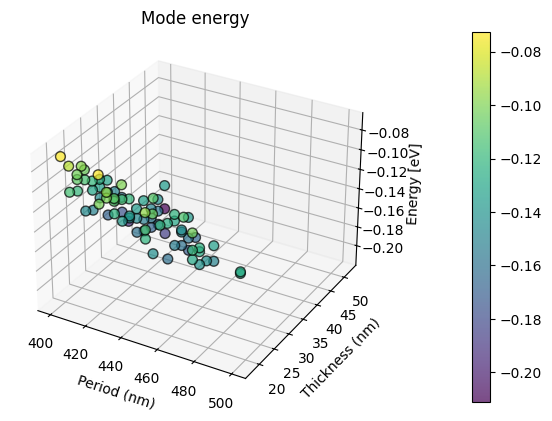

In [7]:
# aim is to plot the mode energies and separation against: period, thickness, filling

# Lists to store filtered data
periods = []
thicknesses = []
mean_energy = []
diff_energy = []

# Extract data
for key, value in data.items():
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        continue
    
   

    temp_vertices:list = []
    temp_thickness:float = None
    temp_period:float = None

    temp_period = float(period)
    temp_thickness = float(thickness)
    
    # Only consider entries with R2 > 0.6
    for i,key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if abs(R2) > 0.6:
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append(vertex)

    if len(temp_vertices) == 2:
        mean_energy.append(np.mean(temp_vertices))
        print(temp_vertices, np.diff(temp_vertices))
        diff_energy.append(float(np.diff(temp_vertices)))
        periods.append(temp_period)
        thicknesses.append(temp_thickness)
    else:
        continue


print((diff_energy))
# Convert lists to numpy arrays for easier manipulation
periods = np.array(periods)
thicknesses = np.array(thicknesses)
energy = np.array(diff_energy)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter1 = ax.scatter(periods, thicknesses, energy, c=energy, 
                      cmap='viridis',
                      marker='o',  # Marker type (circle)
                      s=50,  # Size of markers (points)
                      edgecolor='k',  # Edge color of points (black)
                      alpha=0.7)

fig.colorbar(scatter1)
fig.subplots_adjust(right = 3)
ax.set_xlabel('Period (nm)')
ax.set_ylabel('Thickness (nm)')
ax.set_zlabel('Energy [eV]')
ax.set_title('Mode energy')
plt.show()

/var/folders/pk/mrkz02nn7qd5bc8rndd2bd8c0000gn/T/ipykernel_46548/4101473868.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


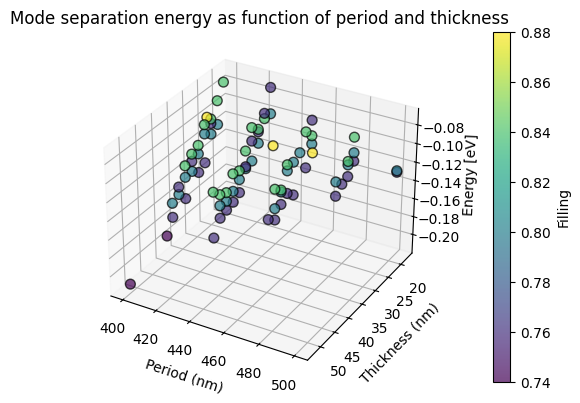

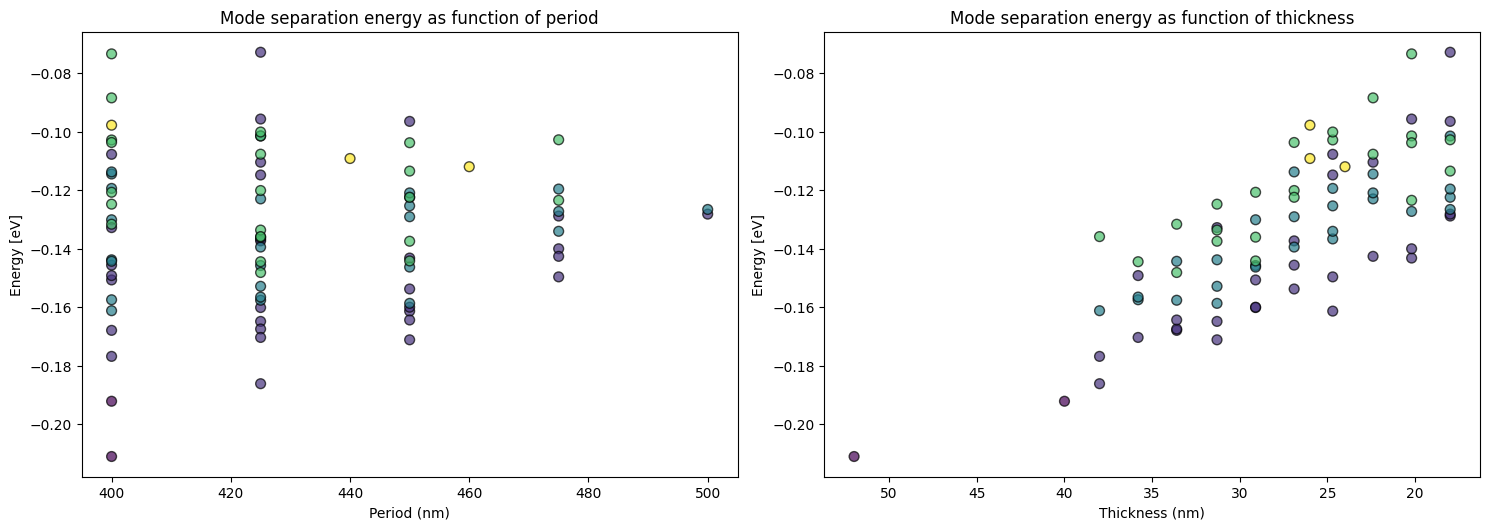

In [11]:

# Lists to store filtered data
df = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])

# Assuming 'data' is your dictionary with the necessary data
for key, value in data.items():
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    ff = float(key_parts[2].split('=')[1].replace('nm', ''))
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        continue
    
    temp_vertices = []

    temp_period = float(period)
    temp_thickness = float(thickness)
    temp_filling = float(ff)
    
    # Only consider entries with R2 > 0.6
    for i, key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if abs(R2) > 0.6:
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to temporary list
            temp_vertices.append(vertex)

    if len(temp_vertices) == 2:
        # Calculate mean energy and difference in energy
        mean_energy_value = np.mean(temp_vertices)
        diff_energy_value = np.diff(temp_vertices)[0]
        
        # Create a new row as a dictionary
        new_row = {
            'period': temp_period,
            'thickness': temp_thickness,
            'filling': temp_filling,
            'mean_energy': mean_energy_value,
            'diff_energy': diff_energy_value
        }
        
        # Append the new row to the DataFrame
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# Convert DataFrame columns to numpy arrays if needed
periods = df['period'].to_numpy()
thicknesses = df['thickness'].to_numpy()
filling = df['filling'].to_numpy()
diff_energy = df['diff_energy'].to_numpy()



# Create a figure with 2 rows and 1 column for the 3D plot above and 2D plots below
fig = plt.figure(figsize=(15, 10))

# 3D Plot
ax1 = fig.add_subplot(211, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label('Filling')
ax1.set_xlabel('Period (nm)')
ax1.set_ylabel('Thickness (nm)')
ax1.set_zlabel('Energy [eV]')
ax1.set_title('Mode separation energy as function of period and thickness')
ax1.invert_yaxis()
plt.show()


fig = plt.figure(figsize=(15, 10))
# 2D plot for Period vs Energy
ax2 = fig.add_subplot(223)
scatter2 = ax2.scatter(periods, energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel('Period (nm)')
ax2.set_ylabel('Energy [eV]')
ax2.set_title('Mode separation energy as function of period')

# 2D plot for Thickness vs Energy
ax3 = fig.add_subplot(224)
scatter3 = ax3.scatter(thicknesses, energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel('Thickness (nm)')
ax3.set_ylabel('Energy [eV]')
ax3.set_title('Mode separation energy as function of thickness')
ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


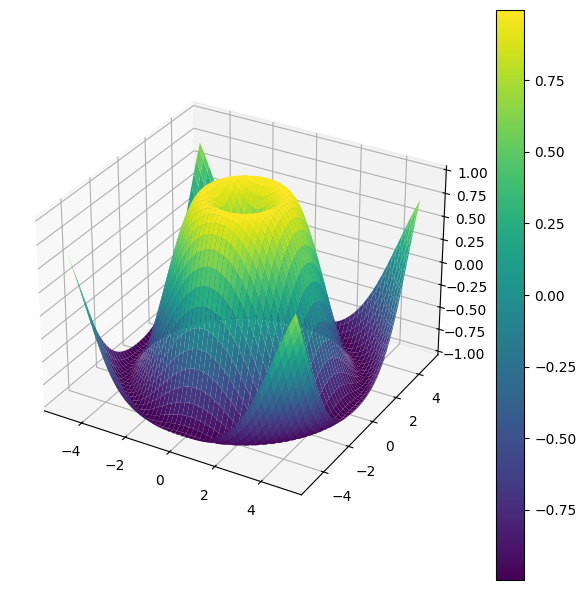

In [20]:
# test 3d plot

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Create a figure
fig = plt.figure(figsize=(12, 6))  # Adjust the figure size for better layout

# Add the first 3D subplot
ax1 = fig.add_subplot(121, projection='3d')  # Use 121 for the first subplot

# Generate data for the plot
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)
z = np.sin(np.sqrt(x**2 + y**2))

# Plot a 3D surface with the viridis colormap on the first subplot
surf1 = ax1.plot_surface(x, y, z, cmap=cm.viridis)

# Add a color bar to provide reference for the colormap of the first plot
fig.colorbar(surf1, ax=ax1)

# Add the second 3D subplot
# ax2 = fig.add_subplot(122, projection='3d')  # Use 122 for the second subplot

# # Plot a 3D surface with the viridis colormap on the second subplot
# surf2 = ax2.plot_surface(x, y, z, cmap=cm.viridis)

# # Add a color bar to provide reference for the colormap of the second plot
# fig.colorbar(surf2, ax=ax2)

# Show the plot
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()